# Distilling Employee Dissatisfaction Themes from Glassdoor Reviews
### Using LDA to Distill Employee Dissatisfaction
**Module:** ITD224 Applied Data Science Project
**Framework:** CRISP-DM

---

## Business Understanding

**Business Goal:** To improve employee engagement and retain valuable staff in an organisation.

**Business Objective (this notebook):** To identify the recurring themes of employee
dissatisfaction from online job reviews ("cons" text) using topic modeling, so that HR can
prioritise concrete, evidence-based actions instead of relying on anecdotes.

**Why topic modeling?** Employees write free-text complaints in their own words. There is no
fixed set of "complaint categories" to filter by — we don't know upfront what the themes are.
Topic modeling (unsupervised learning) is well suited here because it can surface the hidden
themes directly from the text, without needing labelled data.

**Data source:** [Glassdoor Job Reviews (Kaggle)](https://www.kaggle.com/datasets/davidgauthier/glassdoor-job-reviews-2).
For this model answer, reviews from many companies were pooled and treated as one aggregated
organisation.  Though it was meant for a specific company, the technique is the same and is applicable to any.

The dataset used here has already been reduced to 3 relevant columns (`rating`, `cons`, `date`)
from the full ~4GB raw file.

## 0. Setup

In [5]:
import re
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
import logging
# 1. Block standard Python deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*utcnow.*")

# 2. Block underlying library log warnings
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

!pip install gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, Phrases
from gensim.models.phrases import Phraser

from wordcloud import WordCloud

# Reproducibility: LDA involves randomness (random initialisation of topic-word
# distributions) and I will be able to get the same result every time I re-run this notebook.
SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (9, 5)

## 1. Data Understanding (Key Task 2)

We start by loading the data and getting familiar with its shape, quality, and characteristics as required for the Milestone Review's Data Understanding component.

In [6]:
df = pd.read_csv('glassdoor_cons_sample.csv', on_bad_lines='skip')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.info()

Rows: 489,739   Columns: 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489739 entries, 0 to 489738
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   rating  489739 non-null  float64       
 1   cons    489739 non-null  object        
 2   date    489739 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 11.2+ MB


In [7]:
df.head()

,rating,cons,date
0,5.0,They Will work you and keep you on your feet,2016-11-13
1,4.0,There are so many pros of working in this esteemed organization that it overrules the cons it has.,2021-01-25
2,1.0,"Not a bone of leadership displayed by CEO, she talks about it, even had outside coaches but doesn’t know how to prac...",2018-03-17
3,4.0,not so much can be said,2022-09-27
4,5.0,"I have no cons, but full disclosure this company will give you opportunities to grow and challenge you to do so. Th...",2018-04-25


### 1.1 Data fields

| Column | Description |
|---|---|
| `rating` | Overall star rating given by the reviewer (1.0 – 5.0) |
| `cons` | Free-text field where the reviewer describes the downsides of working at the company |
| `date` | Date the review was posted |

We worked with `cons` only, since our business objective is about
**dissatisfaction**.

In [8]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
rating    0
cons      0
date      0
dtype: int64

Duplicate rows: 6485


### 1.2 Rating distribution

Understanding how ratings are distributed, and whether the dataset is skewed toward satisfied or dissatisfied reviewers.

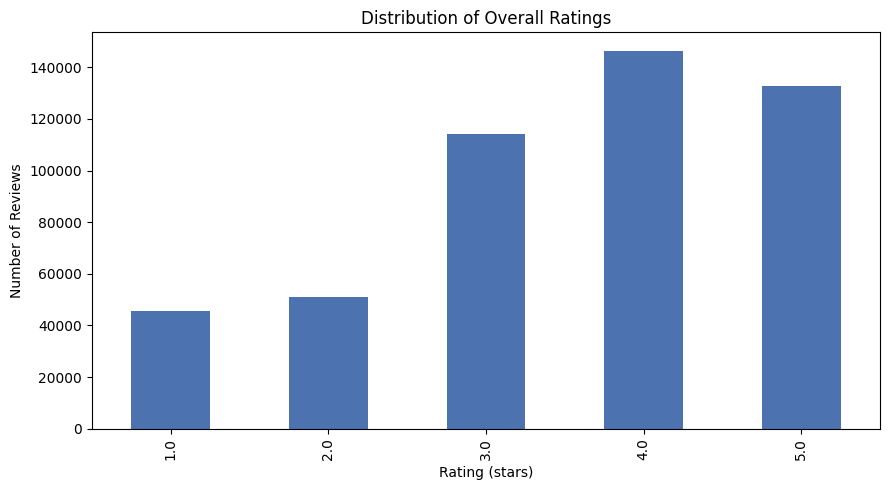

count    489739.000000
mean          3.549195
std           1.248498
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64


In [9]:
fig, ax = plt.subplots()
df['rating'] = pd.to_numeric(df['rating'], errors='coerce') # Ensure 'rating' is numeric, coercing errors
df['rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Distribution of Overall Ratings')
ax.set_xlabel('Rating (stars)')
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

print(df['rating'].describe())

**Observation:** Ratings skew positive (median 4.0) — typical of Glassdoor-style review
platforms, where more satisfied employees tend to leave reviews. This matters for our modelling
approach: even 4–5 star reviewers usually still list at least one "con", so the `cons` field is
a useful source of dissatisfaction signal across the *entire* rating spectrum, not just from
unhappy leavers.

### 1.3 Text length of the `cons` field

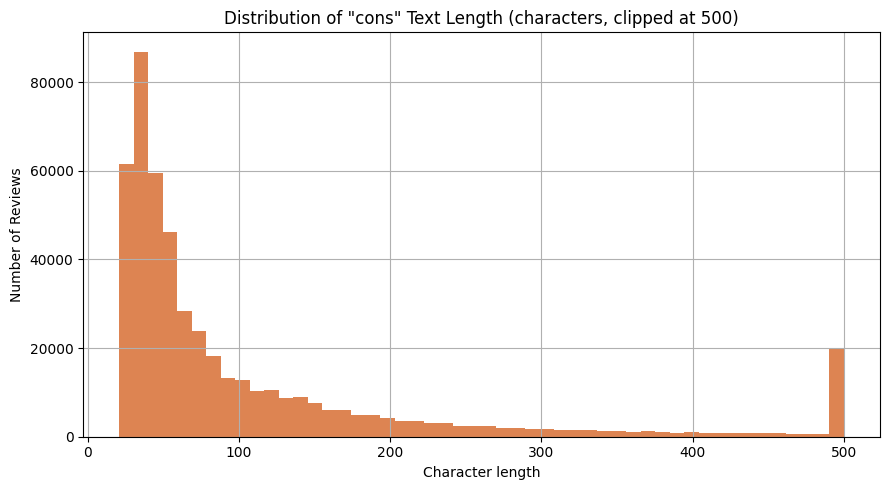

count    489739.000000
mean        125.649993
std         235.208074
min          21.000000
25%          37.000000
50%          57.000000
75%         122.000000
max       14822.000000
Name: cons_len, dtype: float64


In [10]:
df['cons_len'] = df['cons'].str.len()

fig, ax = plt.subplots()
df['cons_len'].clip(upper=500).hist(bins=50, ax=ax, color='#DD8452')
ax.set_title('Distribution of "cons" Text Length (characters, clipped at 500)')
ax.set_xlabel('Character length')
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

print(df['cons_len'].describe())

**Observation:** Most reviews are short — a median of well under 100 characters. LDA was originally designed for longer
documents (e.g. news articles), and short, terse text is harder for it to model cleanly. This is a limitation, and it also motivates using **bigrams** (Section 3.4) to give
the model more informative "tokens" to work with per document.

## 2. Data Preparation (Key Task 3)

### 2.1 Removing uninformative "no cons" responses

Not every reviewer actually has a complaint to share — many "cons" entries are just variations
of "none", "n/a", "nothing to add", etc. These carry no topical information and would only add
noise to the model, so we filter them out.

In [11]:
noise_patterns = [
    r'^no\s*cons?\b', r'^none\b', r'^n/?a\b', r'^nothing\b', r'^nil\b',
    r'^not\s*(much|really|sure|applicable)', r'cannot think of any',
    r"can'?t think of any", r'no complaints', r'nothing (bad|negative)'
]
noise_regex = re.compile('|'.join(noise_patterns), re.IGNORECASE)

# only apply to short entries — a long review that happens to start with "not much" is fine,
# it's genuinely short, generic non-answers we want to catch
is_noise = df['cons'].str.strip().apply(
    lambda x: bool(noise_regex.match(x)) if len(x) < 60 else False
)

print(f"Uninformative 'no cons' style entries found: {is_noise.sum():,} "
      f"({is_noise.mean()*100:.1f}% of all reviews)")
print("\nExamples removed:")
for ex in df.loc[is_noise, 'cons'].sample(5, random_state=SEED):
    print(' -', ex)

df_clean = df.loc[~is_noise].copy()
print(f"\nRemaining reviews: {df_clean.shape[0]:,}")

Uninformative 'no cons' style entries found: 23,671 (4.8% of all reviews)

Examples removed:
 - No cons here good company to work with.
 - none it is a great company
 - Nothing to make note of
 - No cons at all! Great job!
 - none that I can think of

Remaining reviews: 466,068


### 2.2 Sampling down to a manageable modelling set

We have 460K+ usable reviews. LDA is iterative and needs multiple passes over the data to
converge — running it on the full set would be slow to fit and, more importantly, especially when are tuning the number of topics. A well-chosen sample of 18k is both practical and statistically sufficient.

We sample **proportionally within each rating bucket** (low/mid/high) so that we don't accidentally under-represent low-rating reviews — the segment
most relevant to our business objective.

In [12]:
def rating_bucket(r):
    if r <= 2:
        return 'low'
    elif r == 3:
        return 'mid'
    else:
        return 'high'

df_clean['rating_bucket'] = df_clean['rating'].apply(rating_bucket)
print("Rating bucket sizes (before sampling):")
print(df_clean['rating_bucket'].value_counts())

Rating bucket sizes (before sampling):
rating_bucket
high    257226
mid     112386
low      96456
Name: count, dtype: int64


In [13]:
SAMPLE_N = 18000
parts = []
for bucket, grp in df_clean.groupby('rating_bucket'):
    n = min(len(grp), int(SAMPLE_N * len(grp) / len(df_clean)) + 1)
    parts.append(grp.sample(n=n, random_state=SEED))

sample = pd.concat(parts, ignore_index=True)
sample = sample.sample(frac=1, random_state=SEED).reset_index(drop=True)  # shuffle

print(f"\nModelling sample: {sample.shape[0]:,} reviews")
print(sample['rating_bucket'].value_counts())


Modelling sample: 18,002 reviews
rating_bucket
high    9935
mid     4341
low     3726
Name: count, dtype: int64


### 2.3 Text cleaning

Standard NLP cleaning steps:
1. Lowercase everything
2. Strip out punctuation and digits
3. Remove **stopwords**
4. Remove a small set of **domain-specific stopwords** — words common in Glassdoor reviews
   (e.g. "work", "company", "job") that they show up in almost every topic and just add noise
5. **Lemmatize** — reduce words to their base form (e.g. "managers" → "manager") so that
   variants of the same word aren't treated as separate concepts

In [14]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))
extra_stop = {
    'company', 'work', 'working', 'job', 'employee', 'employees',
    'sometimes', 'lot', 'lots', 'get', 'getting', 'also', 'really',
    'much', 'many', 'good', 'great', 'like', 'im', 'ive', 'dont',
    'thats', 'even', 'still', 'sometime', 'things', 'thing', 'people',
    'one', 'would', 'nothing', 'none', 'know', 'make', 'want',
    'con', 'cons', 'something', 'anything', 'always',
    'often', 'well', 'without', 'per', 'every', 'due'
}
stop_words = stop_words.union(extra_stop)


def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)          # keep letters only
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens


sample['tokens'] = sample['cons'].apply(clean_text)

# Drop reviews that ended up with too few meaningful tokens after cleaning —
# there isn't enough signal left in them to meaningfully contribute to a topic
sample = sample[sample['tokens'].apply(len) >= 3].reset_index(drop=True)
print(f"Reviews remaining after cleaning: {sample.shape[0]:,}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Reviews remaining after cleaning: 15,986


In [15]:
print("Before vs after cleaning — example:\n")
for i in [0, 1, 2]:
    print("RAW: ", sample.loc[i, 'cons'])
    print("CLEAN:", sample.loc[i, 'tokens'])
    print()

Before vs after cleaning — example:

RAW:  antiquated systems, low pay in comparison
CLEAN: ['antiquated', 'system', 'low', 'pay', 'comparison']

RAW:  Bad management not enough communication.
CLEAN: ['bad', 'management', 'enough', 'communication']

RAW:  Decent hikes.  Unnecessary  processes for all employee.
CLEAN: ['decent', 'hike', 'unnecessary', 'process']



### 2.4 Bigrams — capturing multi-word phrases

Some of the most meaningful HR concepts are two-word phrases: "worklife balance",
"upper management", "career growth". Treated as separate words, this signal gets diluted. We
use `gensim`'s `Phrases` to automatically detect frequently co-occurring word pairs and merge
them into single tokens (e.g. `life_balance`) before modelling.

In [16]:
bigram_model = Phrases(sample['tokens'], min_count=15, threshold=20)
bigram_phraser = Phraser(bigram_model)
sample['tokens_bigram'] = sample['tokens'].apply(lambda t: bigram_phraser[t])

found_bigrams = [tok for toks in sample['tokens_bigram'] for tok in toks if '_' in tok]
print("Top 15 bigrams discovered in the data:")
for phrase, count in Counter(found_bigrams).most_common(15):
    print(f"  {phrase:<25} {count}")

Top 15 bigrams discovered in the data:
  life_balance              656
  long_hour                 563
  upper_management          294
  full_time                 150
  could_better              114
  minimum_wage              108
  high_turnover             107
  career_growth             97
  customer_service          91
  fast_paced                88
  long_term                 85
  lack_communication        80
  growth_opportunity        79
  decision_making           78
  short_staffed             73


Discovered bigrams for a sanity check — `life_balance`,
`long_hour`, `upper_management`, `high_turnover` and `lack_communication` are exactly the kinds
of HR-relevant phrases we'd expect to see, which gives us confidence the cleaning pipeline on target.

### 2.5 Building the dictionary and corpus

LDA needs text converted into a numeric "bag-of-words" representation:
- A **dictionary** maps every unique word/phrase to an ID
- A **corpus** represents each document as a list of `(word_id, count)` pairs

We also filter out extremely rare words (appearing in fewer than 10 documents — likely typos or
one-off mentions) and extremely common words (appearing in more than 50% of documents — too
generic to define a topic).

In [17]:
dictionary = corpora.Dictionary(sample['tokens_bigram'])
dictionary.filter_extremes(no_below=10, no_above=0.5)
corpus = [dictionary.doc2bow(tokens) for tokens in sample['tokens_bigram']]

print(f"Vocabulary size after filtering: {len(dictionary):,} unique tokens")
print(f"Corpus size: {len(corpus):,} documents")

Vocabulary size after filtering: 2,427 unique tokens
Corpus size: 15,986 documents


## 3. Modelling (Key Task 4)

### 3.1 Selecting the number of topics

LDA requires us to specify the number of topics (*k*) in advance. We use **topic coherence (C_v)** — a metric that measures how semantically related the
top words within each topic are — as our primary evidence, testing several candidate values of
*k*.

In [18]:
coherence_scores = {}
for k in [4, 5, 6, 7, 8, 9, 10]:
    lda_candidate = LdaModel(
        corpus=corpus, id2word=dictionary, num_topics=k,
        random_state=SEED, passes=10, chunksize=2000,
        alpha='auto', eta='auto'
    )
    cm = CoherenceModel(
        model=lda_candidate, texts=sample['tokens_bigram'],
        dictionary=dictionary, coherence='c_v'
    )
    coherence_scores[k] = cm.get_coherence()
    print(f"k={k}  coherence={coherence_scores[k]:.4f}")

k=4  coherence=0.4993
k=5  coherence=0.5028
k=6  coherence=0.4319
k=7  coherence=0.4432
k=8  coherence=0.4467
k=9  coherence=0.4052
k=10  coherence=0.4430


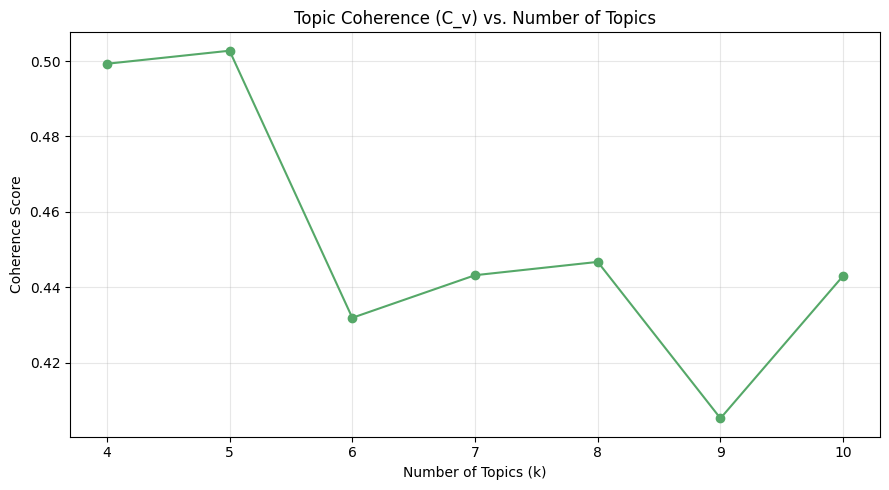

In [19]:
fig, ax = plt.subplots()
ax.plot(list(coherence_scores.keys()), list(coherence_scores.values()), marker='o', color='#55A868')
ax.set_title('Topic Coherence (C_v) vs. Number of Topics')
ax.set_xlabel('Number of Topics (k)')
ax.set_ylabel('Coherence Score')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Choosing k:** Coherence alone doesn't tell the whole story — the highest-scoring *k* isn't
automatically the most useful one for the business.

**k=5** gave near-top coherence *and* produced five topics that are each clearly distinguishable and independently actionable for HR — so that's our final choice. This balances a quantitative metric with qualitative, business-driven judgement.

In [20]:
NUM_TOPICS = 5
lda = LdaModel(
    corpus=corpus, id2word=dictionary, num_topics=NUM_TOPICS,
    random_state=SEED, passes=20, chunksize=2000,
    alpha='auto', eta='auto'
)

final_coherence = CoherenceModel(
    model=lda, texts=sample['tokens_bigram'], dictionary=dictionary, coherence='c_v'
).get_coherence()
print(f"Final model — k={NUM_TOPICS}, coherence={final_coherence:.4f}")

Final model — k=5, coherence=0.4867


### 3.2 Inspecting the topics

In [21]:
for i in range(NUM_TOPICS):
    top_words = lda.show_topic(i, topn=12)
    print(f"Topic {i}: " + ", ".join([w for w, _ in top_words]))

Topic 0: pay, low, salary, less, benefit, bonus, raise, market, bit, company, industry, competitive
Topic 1: change, project, product, technology, large, business, focus, constant, fast, learn, challenging, depends
Topic 2: team, year, hard, new, position, department, career, experience, big, difficult, move, within
Topic 3: time, hour, manager, day, customer, take, store, long, week, sale, care, enough
Topic 4: management, poor, lack, bad, life_balance, need, little, long_hour, slow, opportunity, staff, leadership


### 3.3 Word clouds

A quick, intuitive visual for each topic's most weighted words — useful for presenting results
to a non-technical HR audience.

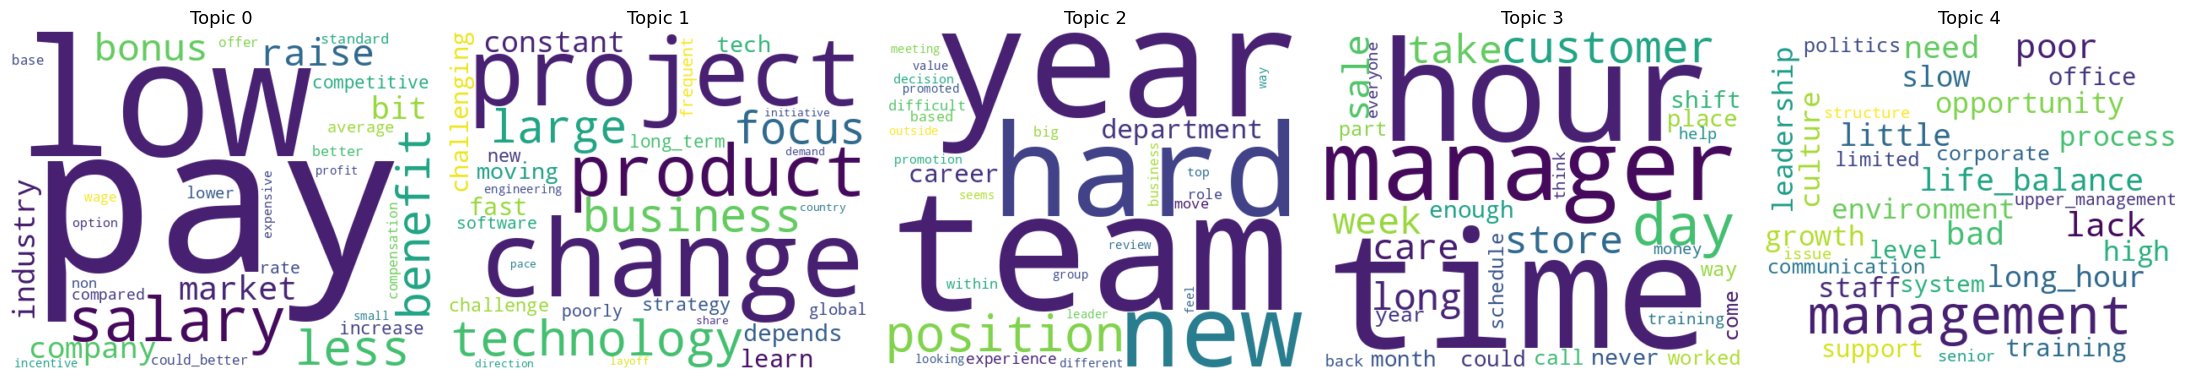

In [22]:
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(22, 5))
for i in range(NUM_TOPICS):
    word_freq = dict(lda.show_topic(i, topn=30))
    wc = WordCloud(width=500, height=400, background_color='white',
                    colormap='viridis', random_state=SEED).generate_from_frequencies(word_freq)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Topic {i}', fontsize=13)
plt.tight_layout()
plt.show()

In [33]:
!pip install pyldavis -q

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

import warnings
import logging
# 1. Block standard Python deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*utcnow.*")

# 2. Block underlying library log warnings
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.145368  0.188674       1        1  41.770029
4     -0.059308 -0.012710       2        1  21.729689
2     -0.170226  0.104475       3        1  19.835081
0      0.394494  0.094096       4        1  10.683359
1     -0.019591 -0.374535       5        1   5.981842, topic_info=            Term         Freq        Total Category  logprob  loglift
3            pay  1934.000000  1934.000000  Default  30.0000  30.0000
8     management  2930.000000  2930.000000  Default  29.0000  29.0000
2            low  1131.000000  1131.000000  Default  28.0000  28.0000
129       salary  1075.000000  1075.000000  Default  27.0000  27.0000
17        change   761.000000   761.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1687    struggle    48.157147    52.217069   Topic5  -5.2812   2.7355
1575      demand    55.465952    78.339090   Topic5  -5.1399   2.4712
79           new    89.055320   604.457120   Topic5  -4.6664   0.9014
1183      layoff    56.068163   120.486467   Topic5  -5.1291   2.0515
638    direction    53.433838   161.715439   Topic5  -5.1773   1.7090

[270 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
708       3  0.995379       across
385       3  0.988583      advance
91        2  0.989210  advancement
91        3  0.008716  advancement
1057      2  0.994627        among
...     ...       ...          ...
102       2  0.003739       worker
353       2  0.994210     workload
47        1  0.316858         year
47        3  0.625473         year
47        4  0.056778         year

[365 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 5, 3, 1, 2])

#Observation

We see that Topic 3 has a significant overlap with Topic 0 - that of Pay and Career Growth.
This is not unexpected as both a related to a certain extent.  It can also be due to the size of the companies involved.

However, for most of the other topics, there are significant separation and provides us with good confidence that the topic number is good.

### 3.4 Naming the topics

Based on the top words and word clouds above, we assign each topic a human-readable label. This
step is a judgement call, not a computed value — it maybe justified with supporting keywords shown below.

| Topic | Top Keywords | Label | Rationale |
|---|---|---|---|
| 0 | pay, salary, low, benefit, less, bonus, raise, market, competitive | **Pay & Compensation** | Directly about compensation adequacy vs. market |
| 1 | change, project, product, technology, business, constant, fast, challenging | **Business Change & Pace** | Organisational/strategic churn and fast-paced pressure |
| 2 | team, career, position, department, move, role, experience | **Career Growth & Roles** | Internal mobility and role/career development friction |
| 3 | time, hour, manager, day, customer, store, shift, week | **Workload, Hours & Day-to-Day Management** | Scheduling, shift work, and frontline supervision issues |
| 4 | management, poor, lack, bad, life_balance, long_hour, leadership, growth | **Poor Leadership & Work-Life Balance** | Senior leadership quality and work-life balance complaints |

In [36]:
import warnings
import logging
# 1. Block standard Python deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*utcnow.*")

# 2. Block underlying library log warnings
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

topic_labels = {
    0: 'Pay & Compensation',
    1: 'Business Change & Pace',
    2: 'Career Growth & Roles',
    3: 'Workload, Hours & Day-to-Day Management',
    4: 'Poor Leadership & Work-Life Balance',
}

## 4. Evaluation (Key Task 4 / CRISP-DM Evaluation phase)

### 4.1 Assigning topics to reviews

For each review, we compute its full topic *distribution* (how much of each topic it contains)
and record the single **dominant topic** — the topic with the highest weight.

In [37]:
topic_weight_matrix = np.zeros((len(corpus), NUM_TOPICS))
dominant_topic = []

for i, bow in enumerate(corpus):
    dist = lda.get_document_topics(bow, minimum_probability=0)
    for topic_id, weight in dist:
        topic_weight_matrix[i, topic_id] = weight
    dominant_topic.append(max(dist, key=lambda x: x[1])[0])

for t in range(NUM_TOPICS):
    sample[f'topic_{t}_weight'] = topic_weight_matrix[:, t]
sample['dominant_topic'] = dominant_topic
sample['dominant_topic_label'] = sample['dominant_topic'].map(topic_labels)

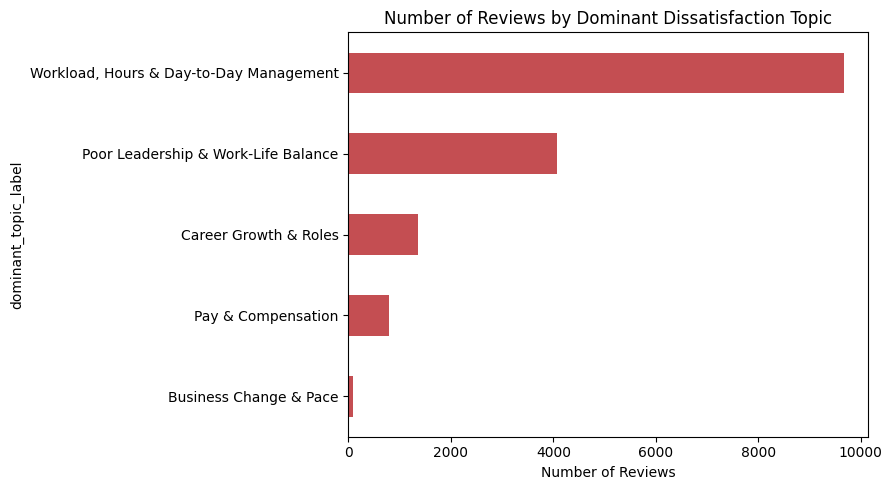

dominant_topic_label
Workload, Hours & Day-to-Day Management    9668
Poor Leadership & Work-Life Balance        4077
Career Growth & Roles                      1354
Pay & Compensation                          800
Business Change & Pace                       87
Name: count, dtype: int64

dominant_topic_label
Workload, Hours & Day-to-Day Management    60.5
Poor Leadership & Work-Life Balance        25.5
Career Growth & Roles                       8.5
Pay & Compensation                          5.0
Business Change & Pace                      0.5
Name: count, dtype: float64% of reviews respectively


In [38]:
import warnings
import logging
# 1. Block standard Python deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*utcnow.*")

# 2. Block underlying library log warnings
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

fig, ax = plt.subplots()
counts = sample['dominant_topic_label'].value_counts()
counts.plot(kind='barh', ax=ax, color='#C44E52')
ax.set_title('Number of Reviews by Dominant Dissatisfaction Topic')
ax.set_xlabel('Number of Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(counts)
print(f"\n{(counts / counts.sum() * 100).round(1)}% of reviews respectively")

**Observation — an honest limitation, not a clean result:** Topic 3 (Workload, Hours &
Day-to-Day Management) dominates the hard topic assignment, capturing well over half of all
reviews. We thus also look at **soft topic weights** below rather than relying on the single dominant topic alone.

### 4.2 Does dissatisfaction differ by rating? Cross-referencing topics with `rating`

This is the key step that turns "what are people unhappy about" into "what should HR act on
first" — by checking whether certain topics are disproportionately present among *low*-rating
reviewers compared to *high*-rating reviewers.

In [39]:
import warnings
import logging
# 1. Block standard Python deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*utcnow.*")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

# 2. Block underlying library log warnings
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

avg_by_bucket = sample.groupby('rating_bucket')[[f'topic_{t}_weight' for t in range(NUM_TOPICS)]].mean()
avg_by_bucket.columns = [topic_labels[t] for t in range(NUM_TOPICS)]
avg_by_bucket = avg_by_bucket.reindex(['low', 'mid', 'high'])
avg_by_bucket

,Pay & Compensation,Business Change & Pace,Career Growth & Roles,"Workload, Hours & Day-to-Day Management",Poor Leadership & Work-Life Balance
rating_bucket,,,,,
low,0.106933,0.055388,0.182204,0.403854,0.251622
mid,0.123700,0.062947,0.184030,0.364900,0.264425
high,0.125806,0.069187,0.182422,0.372494,0.250090


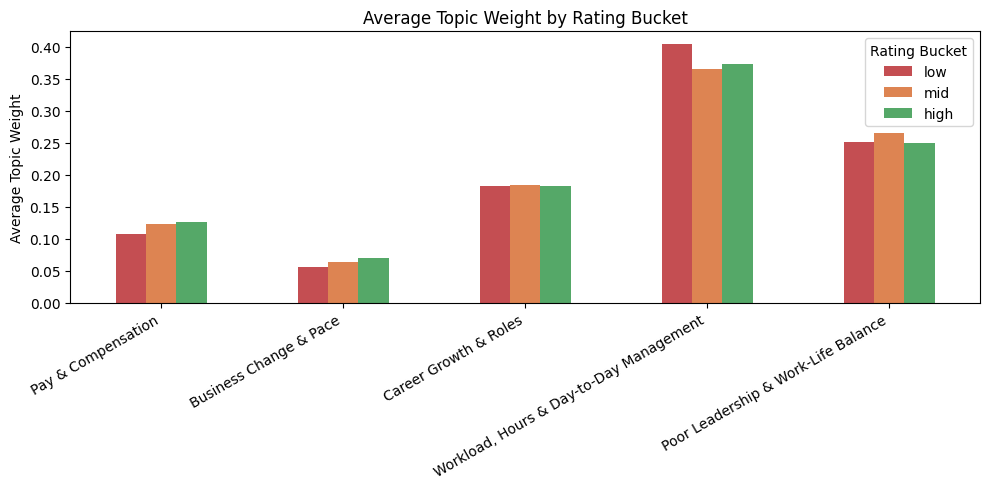

In [40]:
import warnings
import logging
# 1. Block standard Python deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*utcnow.*")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

fig, ax = plt.subplots(figsize=(10, 5))
avg_by_bucket.T.plot(kind='bar', ax=ax, color=['#C44E52', '#DD8452', '#55A868'])
ax.set_title('Average Topic Weight by Rating Bucket')
ax.set_ylabel('Average Topic Weight')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Rating Bucket')
plt.tight_layout()
plt.show()

**Interpretation — this is more nuanced than expected, and that's an important finding in
itself:**

- The differences in average topic weight *across rating buckets are relatively small*. This
  makes sense once we remember what `cons` actually captures: **even 5-star reviewers were
  asked to list a downside**, so the topic mix in `cons` reflects near-universal friction
  points, not necessarily what's driving someone to churn.
- **Pay & Compensation** is, proportionally, mentioned *more* among high-rating reviewers than
  low-rating reviewers. A plausible read: for genuinely satisfied employees, pay is often their
  *only* real complaint — so it dominates their (otherwise short) cons list. For dissatisfied
  employees, pay is just one grievance among several bigger ones.
- **Poor Leadership & Work-Life Balance** (Topic 4) is highest among **mid (3-star)** reviewers,
  not low-rating ones. This is a genuinely useful, non-obvious finding for HR: 3-star reviewers
  represent a "passively dissatisfied" segment — not disengaged enough to leave a scathing
  review, but clearly signalling leadership and work-life friction. This group is often
  overlooked because they don't generate loud complaints, yet they may be the most responsive to
  proactive intervention before they become 1-star leavers.

### 4.3 Representative examples per topic

Quantitative topic-word lists are useful, but HR stakeholders relate much more easily to actual
quotes. Here are the highest-topic-weight example reviews for each theme, to ground the
keywords in real employee language.

We can see that Topic 3, the language seems to be more vitriolic and strident.  It carries high emotional content that just pure LDA modeling may not capture.

In [41]:
import warnings
import logging
# 1. Block standard Python deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*utcnow.*")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

for t in range(NUM_TOPICS):
    print(f"\n=== Topic {t}: {topic_labels[t]} ===")
    top_examples = (sample[sample['dominant_topic'] == t]
                     .sort_values(f'topic_{t}_weight', ascending=False)
                     .head(3))
    for _, row in top_examples.iterrows():
        snippet = row['cons'][:150].replace('\n', ' ').replace('\r', ' ')
        print(f"  ({row['rating']:.0f}★) {snippet}...")


=== Topic 0: Pay & Compensation ===
  (3★) Offer very low pay, compared to insurance coverage for the child’s services....
  (5★) Weaker additional benefits package comparing to market, modest raise in salary not always matching inflation pace...
  (3★) Low Pay  2014 Benefits costing more and LESS coverage (Health and Dental)  No raises until 2015...

=== Topic 1: Business Change & Pace ===
  (4★) High workload and ineffective prioritization by leadership and managers creates employee burnout/frustration and failure to focus on highest prioritie...
  (3★) Uncertainty due to constant change. Strategic direction was fuzzy....
  (1★) 1. No work life balance  2. Most of the projects are bug fixes(maintenance).  3. Less work Less challenges Outcome less exposure.  4. Not recommended ...

=== Topic 2: Career Growth & Roles ===
  (3★) Cons based on the team which you are joining...In Oracle there is a team called Shared pool ,if you join in that team.u feel like u are in school...Te...
  (5★

## 5. Business Recommendations for HR

Grounded in the topic keywords, prevalence, and rating cross-tabs above:

1. **Prioritise the "passively dissatisfied" 3-star segment for leadership & work-life
   initiatives.** This group shows the highest weighting on the Poor Leadership & Work-Life
   Balance topic, yet is easy to miss in exit-interview-style analysis that only looks at 1-star
   reviews. A pulse-survey follow-up targeted at 3-star reviewers specifically could catch
   retention risk earlier.
2. **Investigate frontline scheduling practices.** Workload, Hours & Day-to-Day Management is
   the single largest topic by volume across *all* rating levels — long hours, shift
   unpredictability, and frontline manager friction are close to a baseline complaint, not
   isolated to unhappy leavers. This points to a structural/operational issue (e.g. staffing
   levels, shift design) rather than an individual-manager problem.
3. **Treat pay competitiveness as a "hygiene factor," not just a churn driver.** Since Pay &
   Compensation shows up proportionally *more* among satisfied employees, benchmarking pay
   against market rate may do more to *prevent* dissatisfaction from emerging in an otherwise
   engaged workforce than it does to *win back* already-disengaged employees — those employees'
   complaints are dominated by other, larger issues.
4. **Career Growth & Roles** and **Business Change & Pace** are smaller in volume but still
   consistently present — worth monitoring as secondary themes, particularly the sub-signal
   around unclear promotion paths and mobility across teams.

These recommendations should be validated with a follow-up, more targeted data collection
effort (e.g. a structured HR pulse survey referencing these exact themes) before committing to
budget or policy changes — topic modeling surfaces *what people are talking about*, not proof of
*causal* drivers of attrition.

## 6. Limitations

- **Aggregated company assumption.** This model answer pools reviews across many companies and treats them as one organisation. The project submission here is to practise and exercise data science skills but it still can be used for company-specific or company-comparative topic modelling.
- **Short-text limitation of LDA.** As shown in Section 4.1, LDA's hard topic assignment skews toward broader topics when documents are short. Reporting soft topic weights (Section 4.2) partially mitigates this, but a short-text-specific model (e.g. GSDMM) would be a natural next step.
- **No sarcasm/context understanding.** LDA is a bag-of-words model — it has no understanding of negation, sarcasm, or sentence structure. "Not enough pay" and "enough pay, not the issue" would contribute identical tokens.
- **Selection bias.** Only employees motivated enough to write a review are represented — this likely skews toward more extreme (very satisfied or very dissatisfied) opinions and may under-represent quieter, disengaged employees who never write a review at all.
- **Privacy & fairness.** Even anonymised review text can occasionally contain identifying details (specific team names, dates, incidents). If this technique were deployed in a real HR setting, reviews should be handled with the same confidentiality safeguards as any other employee feedback channel, and HR should be transparent with staff that review-mining informs HR action — to avoid a chilling effect on honest future feedback. **AI Ethics Consideration**

## 7. Conclusion

This notebook applied the CRISP-DM framework to distil unstructured Glassdoor "cons" reviews into five interpretable dissatisfaction themes using LDA topic modeling, evaluated topic count selection using coherence scoring, and cross-referenced topic prevalence against review ratings
to surface an actionable, evidence-grounded insight (the "passively dissatisfied" 3-star segment) that a purely rating-based analysis would have missed.

##Alternative Model Experiment: NMF

LDA is a probabilistic model — it assumes documents are mixtures of topics drawn from Dirichlet priors, which is why it needs alpha/eta and multiple training passes to converge. Non-negative Matrix Factorisation (NMF) is a simpler, purely algebraic alternative: it factorises a document-term (TF-IDF) matrix directly into two non-negative matrices, with no randomness to tune beyond the number of components. It reuses the already-cleaned tokens directly, is deterministic given the same TF-IDF input, and can be scored on the exact same C_v coherence metric as LDA for a fair, like-for-like comparison.



In [42]:
import warnings
import logging
# 1. Block standard Python deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*utcnow.*")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from gensim.models import CoherenceModel

# NMF works on a TF-IDF matrix rather than gensim's bag-of-words corpus, but it can
# reuse our already-cleaned tokens directly -- no extra data prep needed.
docs_for_nmf = [" ".join(toks) for toks in sample['tokens_bigram']]

tfidf_vectorizer = TfidfVectorizer(max_df=0.5, min_df=10)
tfidf_matrix = tfidf_vectorizer.fit_transform(docs_for_nmf)
feature_names = tfidf_vectorizer.get_feature_names_out()

nmf = NMF(n_components=NUM_TOPICS, random_state=SEED, init='nndsvd', max_iter=500)
nmf.fit(tfidf_matrix)

def nmf_top_words(model, feature_names, topn=12):
    topics = []
    for topic in model.components_:
        top_idx = topic.argsort()[:-topn - 1:-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics

nmf_topics = nmf_top_words(nmf, feature_names)
print("NMF topics:")
for i, words in enumerate(nmf_topics):
    print(f"Topic {i}: " + ", ".join(words))

# Apples-to-apples comparison: gensim's CoherenceModel can score any list of
# word-lists, so we can compare NMF's topics against LDA's using the same metric.
lda_topics = [[w for w, _ in lda.show_topic(i, topn=12)] for i in range(NUM_TOPICS)]

lda_coherence = CoherenceModel(topics=lda_topics, texts=sample['tokens_bigram'],
                                dictionary=dictionary, coherence='c_v').get_coherence()
nmf_coherence = CoherenceModel(topics=nmf_topics, texts=sample['tokens_bigram'],
                                dictionary=dictionary, coherence='c_v').get_coherence()

print(f"\nLDA coherence: {lda_coherence:.4f}")
print(f"NMF coherence: {nmf_coherence:.4f}")

NMF topics:
Topic 0: management, poor, bad, lack, manager, need, communication, care, team, senior, leadership, staff
Topic 1: pay, low, benefit, enough, raise, compared, rate, average, amount, could_better, wage, bonus
Topic 2: time, hour, long, day, shift, week, take, enough, manager, hard, customer, part
Topic 3: salary, less, low, growth, slow, opportunity, market, competitive, promotion, lower, increase, hike
Topic 4: long_hour, life_balance, difficult, hard, stressful, environment, poor, project, expected, weekend, tiring, pressure

LDA coherence: 0.4998
NMF coherence: 0.5063


Bottom line: both models extract the same underlying signal, but spend their fixed five-topic budget differently. LDA keeps all five HR themes distinct (including Organisational Change, which has no clear NMF counterpart) at the cost of leaving pay/hours/work-life balance somewhat coarse. NMF resolves pay/hours into three finer slices at the cost of losing Organisational Change as a distinct theme, and folding Career Growth into a salary-and-promotion topic rather than keeping it separate. Neither model is unconditionally “better” — the right choice depends on whether the business question needs a fine-grained view of compensation language (NMF) or full coverage of all five HR themes including organisational/strategic friction (LDA).